# Model comparison

This notebook implements the analysis in the dissertation plan. It compares
three methods across five treatment-effect scenarios.

The notebook follows the simulation procedure in order:

1. Create one fixed evaluation population.
2. Simulate a randomised trial for each scenario.
3. Fit the classical, Bayesian, and causal-forest methods to the same trial.
4. Compare their estimates with the known simulation truth.
5. Repeat the process and summarise bias, RMSE, coverage, and CATE RMSE.

The synthetic data generator and scenario definitions are kept in
`config.py`. The separately gated tuning experiment below reuses these
functions without changing the main comparison.

In [1]:
from itertools import product
import logging
from time import perf_counter
import warnings

# Hide the missing widget warning from tqdm
warnings.filterwarnings("ignore", message="IProgress not found")

import arviz as az
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.optimize import approx_fprime
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from tqdm.auto import tqdm

import config as cfg

# Hide routine PyMC sampling messages
logging.getLogger("pymc").setLevel(logging.ERROR)

## Analysis settings

All random components derive from `RANDOM_SEED = 42` in `config.py`.
Independent random streams are created for calibration, evaluation, trial
generation, model fitting, prior sensitivity, and causal-forest tuning.

In [2]:
# Create the output folder
OUTPUT_DIRECTORY = cfg.RESULTS_DIRECTORY
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Choose the pilot or final main run
FINAL_RUN = True
RUN_MAIN_ANALYSIS = True
RUN_PRIOR_SENSITIVITY = True
RUN_CAUSAL_FOREST_TUNING = False

if FINAL_RUN:
    N_REPLICATIONS = cfg.MONTE_CARLO_REPLICATIONS
else:
    N_REPLICATIONS = cfg.PILOT_REPLICATIONS

# Set Bayesian sampling values
BAYES_DRAWS = 500
BAYES_TUNE = 500
MCMC_CHAINS = 2
MINIMUM_BULK_ESS = 100

# Set prior scales for sensitivity analysis
PRIOR_SCALES = [0.5, 1.0, 2.0]

## Data preparation and evaluation functions

Every method predicts an individual conditional average treatment effect,
or CATE, for each person in the fixed evaluation population.

The primary estimate is the difference between the mean CATE in the two
prespecified groups for that scenario.

In [3]:
def normal_interval(estimate, standard_error):
    """Return a normal 95% interval in a small dictionary"""
    estimate = float(estimate)
    standard_error = float(standard_error)

    # Use a normal approximation
    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "lower": estimate - 1.96 * standard_error,
        "upper": estimate + 1.96 * standard_error
    }

def posterior_interval(draws):
    """Summarise posterior draws using their mean, SD, and 95% interval"""
    draws = np.asarray(draws, dtype=float).reshape(-1)
    # Calculate the 2.5% and 97.5% quantiles
    lower, upper = np.quantile(draws, [0.025, 0.975])

    return {
        # Use the posterior mean as the point estimate
        "estimate": float(draws.mean()),
        # Use the posterior standard deviation as the standard error
        "standard_error": float(draws.std(ddof=1)),
        "lower": float(lower),
        "upper": float(upper)
    }

def subgroup_difference(cate, comparison):
    """Compare the mean CATE in group one with the mean in group zero"""
    # Compare the two group averages
    group_one_effect = cate[comparison["group_one"]].mean()
    group_zero_effect = cate[comparison["group_zero"]].mean()
    return float(group_one_effect - group_zero_effect)

MODEL_FACTOR_COLUMNS = ["female", "age_65", "bmi_35_to_40", "bmi_40", "prediabetes"]

def prepare_analysis_data(data):
    """Add model factors from the subgroup labels created in config.py"""
    prepared = data.copy()
    prepared["age_65"] = prepared["age_group"].eq("65 or older").astype(int)
    prepared["bmi_35_to_40"] = prepared["bmi_group"].eq("35 to under 40").astype(int)
    prepared["bmi_40"] = prepared["bmi_group"].eq("40 or higher").astype(int)
    return prepared

def calculate_truth(evaluation_data, scenario):
    """Calculate the known truth for one scenario"""
    # Use hidden probabilities only for evaluation
    placebo_probability, treated_probability = cfg.calculate_outcome_probabilities(
        evaluation_data, scenario
    )
    true_cate = treated_probability - placebo_probability
    comparison = cfg.subgroup_comparison(evaluation_data, scenario)

    return {
        "cate": true_cate,
        "subgroup_difference": subgroup_difference(true_cate, comparison)
    }

## Method 1. Classical interaction model

The classical model is a logistic regression. It contains treatment, five
subgroup indicators, and the five treatment by subgroup interactions.

weight_loss_5pct ~ treated * (female + age_65 + bmi_35_to_40 + bmi_40 + prediabetes)

In [4]:
def make_classical_design(data, treatment):
    """Create the columns used in the classical logistic regression"""
    # Use one treatment value for every row when needed
    if np.isscalar(treatment):
        treated = np.repeat(treatment, len(data))
    else:
        treated = np.asarray(treatment)

    # Reuse the subgroup indicators above
    subgroup_design = data[MODEL_FACTOR_COLUMNS]
    main_design = pd.DataFrame({"intercept": 1.0, "treated": treated}, index=data.index)
    interactions = subgroup_design.mul(treated, axis=0).add_prefix("treated_x_")
    return pd.concat([main_design, subgroup_design, interactions], axis=1)

def predict_classical_cate(coefficients, evaluation_data):
    """Predict each person's risk under treatment and placebo"""
    # Predict the same people under both arms
    treated_design = make_classical_design(evaluation_data, treatment=1)
    placebo_design = make_classical_design(evaluation_data, treatment=0)

    treated_risk = cfg.inverse_logit(treated_design @ coefficients)
    placebo_risk = cfg.inverse_logit(placebo_design @ coefficients)

    return treated_risk - placebo_risk

The delta method needs the slope of the subgroup difference with respect to
every regression coefficient. `approx_fprime` calculates these slopes by
making a very small change to each coefficient. This avoids writing the
matrix derivative by hand while keeping the same delta-method analysis.

In [5]:
def fit_classical_model(data, evaluation_data, scenario):
    """Fit the classical model and return the results"""
    # Create the design matrix for the classical logistic regression
    observed_design = make_classical_design(data, treatment=data["treated"].to_numpy())

    # Fit logistic regression with heteroskedasticity-robust standard errors
    fitted_model = sm.GLM(
        data["weight_loss_5pct"], observed_design, family=sm.families.Binomial()
    ).fit(cov_type="HC0", maxiter=100)

    # Extract coefficients and covariance matrix
    coefficients = fitted_model.params.to_numpy()
    covariance = fitted_model.cov_params().to_numpy()
    comparison = cfg.subgroup_comparison(evaluation_data, scenario)

    # Estimate individual and subgroup effects
    cate = predict_classical_cate(coefficients, evaluation_data)
    point_estimate = subgroup_difference(cate, comparison)

    # Recalculate the subgroup difference after small coefficient changes
    def recalculate_difference(changed_coefficients):
        changed_cate = predict_classical_cate(changed_coefficients, evaluation_data)
        return subgroup_difference(changed_cate, comparison)

    # Approximate the delta method gradient
    gradient = approx_fprime(coefficients, recalculate_difference, epsilon=1e-6)
    variance = gradient @ covariance @ gradient
    standard_error = np.sqrt(max(float(variance), 0))

    return {
        "method": "classical_interaction",
        "subgroup_result": normal_interval(point_estimate, standard_error),
        "cate": cate,
        "converged": bool(fitted_model.converged),
        "diagnostic": ""
    }

## Method 2. Bayesian hierarchical model

Sex, age group, BMI group, and prediabetes define 24 possible strata.
Each participant is assigned a stratum number from 0 to 23.

The observed outcomes are then counted within each treatment arm and
stratum. The resulting 48 binomial observations contain all information
needed by this model and make sampling much faster.

In [6]:
N_STRATA = 24

def find_stratum(data):
    """Assign every participant to one of the 24 strata"""
    indicators = data[MODEL_FACTOR_COLUMNS]
    bmi_group = indicators["bmi_35_to_40"] + 2 * indicators["bmi_40"]

    # Give each factor combination one index
    stratum = (
        indicators["female"] * 12
        + indicators["age_65"] * 6
        + bmi_group * 2
        + indicators["prediabetes"]
    )
    return stratum.to_numpy(dtype=int)

def count_stratum_outcomes(data):
    """Count participants and responses by arm and stratum"""
    stratum = find_stratum(data)
    treated = data["treated"].to_numpy(dtype=int)
    outcome = data["weight_loss_5pct"].to_numpy(dtype=int)

    # Store placebo in row 0 and treatment in row 1
    totals = np.zeros((2, N_STRATA), dtype=int)
    responses = np.zeros((2, N_STRATA), dtype=int)

    # Count participants and responses
    for arm in [0, 1]:
        in_arm = treated == arm
        totals[arm] = np.bincount(stratum[in_arm], minlength=N_STRATA)
        responses[arm] = np.bincount(
            stratum[in_arm], weights=outcome[in_arm], minlength=N_STRATA
        ).astype(int)

    return totals, responses

In [7]:
def fit_bayesian_model(data, evaluation_data, scenario, fit_seed, prior_scale=1.0):
    """Fit the Bayesian hierarchical model"""
    totals, responses = count_stratum_outcomes(data)

    with pm.Model() as model:
        # Set arm-level priors
        global_log_odds = pm.Normal("global_log_odds", mu=0, sigma=3, shape=2)
        heterogeneity = pm.HalfNormal("heterogeneity", sigma=prior_scale, shape=2)
        # Set partially pooled stratum effects
        stratum_z = pm.Normal("stratum_z", mu=0, sigma=1, shape=(2, N_STRATA))
        # Calculate stratum-specific log-odds
        log_odds = global_log_odds[:, None] + heterogeneity[:, None] * stratum_z
        # Convert log-odds to probabilities
        probability = pm.Deterministic("probability", pm.math.sigmoid(log_odds))

        # Use aggregated binomial observations
        pm.Binomial("responses", n=totals, p=probability, observed=responses)

        # Draw from the posterior
        posterior = pm.sample(
            draws=BAYES_DRAWS,
            tune=BAYES_TUNE,
            chains=MCMC_CHAINS,
            cores=1,
            target_accept=0.95,
            random_seed=fit_seed,
            progressbar=False,
            compute_convergence_checks=False
        )

    # Extract the probability draws
    probability_draws = np.asarray(posterior.posterior["probability"], dtype=float)
    # Assign evaluation participants to strata
    evaluation_stratum = find_stratum(evaluation_data)

    # Convert arm probabilities into CATE draws
    cate_draws = (
        probability_draws[:, :, 1, evaluation_stratum]
        - probability_draws[:, :, 0, evaluation_stratum]
    )

    # Calculate the subgroup difference for every draw
    comparison = cfg.subgroup_comparison(evaluation_data, scenario)
    subgroup_draws = cate_draws[:, :, comparison["group_one"]].mean(
        axis=2
    ) - cate_draws[:, :, comparison["group_zero"]].mean(axis=2)

    # Calculate diagnostics for model parameters
    model_diagnostics = az.summary(
        posterior, var_names=["global_log_odds", "heterogeneity", "probability"]
    )
    # Check the maximum R-hat, which should be close to one
    max_rhat = float(model_diagnostics["r_hat"].max())
    # Check minimum bulk effective sample size (the larger the better)
    minimum_bulk_ess = float(model_diagnostics["ess_bulk"].min())

    # Check the primary subgroup estimate
    subgroup_rhat = float(np.asarray(az.rhat(subgroup_draws)))
    subgroup_ess = float(np.asarray(az.ess(subgroup_draws, method="bulk")))
    # Combine the diagnostics results
    max_rhat = max(max_rhat, subgroup_rhat)
    minimum_bulk_ess = min(minimum_bulk_ess, subgroup_ess)

    # Check for divergences (ideally zero)
    divergences = int(posterior.sample_stats["diverging"].sum())

    # Mark the model as converged only when every diagnostic passes
    converged = (
        max_rhat < 1.05 and minimum_bulk_ess >= MINIMUM_BULK_ESS and divergences == 0
    )

    # Calculate the posterior mean CATE
    mean_cate = cate_draws.mean(axis=(0, 1))

    return {
        "method": "bayesian_hierarchical",
        "subgroup_result": posterior_interval(subgroup_draws),
        "cate": mean_cate,
        "converged": converged,
        "diagnostic": (
            f"prior scale={prior_scale:g}, "
            f"max R-hat={max_rhat:.3f}, "
            f"minimum bulk ESS={minimum_bulk_ess:.0f}, "
            f"divergences={divergences}"
        )
    }

## Method 3. Causal forest

EconML handles the causal-forest fitting. The function below supplies the
baseline variables, outcome, and randomised treatment indicator.

The subgroup interval combines the two subgroup variances. Their covariance
is not available from this interface, so causal-forest coverage is treated
as a secondary result.

In [8]:
def get_baseline_features(data):
    """Return the baseline variables used by the causal forest"""
    return data[cfg.BASELINE_COLUMNS].to_numpy(dtype=float)

def population_standard_error(effect_inference):
    """Get the standard error of a population mean effect"""
    summary = effect_inference.population_summary(alpha=0.05)
    return float(np.asarray(summary.stderr_mean).squeeze())

# Final causal-forest settings selected by tuning
CAUSAL_FOREST_SETTINGS = {
    "min_samples_leaf": 20,
    "max_samples": 0.45,
    "max_depth": 5
}

CAUSAL_FOREST_TUNING_REPLICATIONS = 30

# Candidate settings used for tuning
CAUSAL_FOREST_TUNING_GRID = {
    "min_samples_leaf": (5, 10, 20),
    "max_samples": (0.45, 0.50),
    "max_depth": (None, 5)
}

def fit_causal_forest(
    data, evaluation_data, scenario, fit_seed, forest_settings=None
):
    """Fit the causal forest and return the required results"""
    settings = (
        CAUSAL_FOREST_SETTINGS
        if forest_settings is None
        else forest_settings
    )

    # Define the nuisance and forest models
    forest = CausalForestDML(
        model_y=RandomForestClassifier(
            n_estimators=100,
            min_samples_leaf=10,
            max_features="sqrt",
            random_state=fit_seed,
            n_jobs=1
        ),
        model_t=DummyClassifier(strategy="prior"),
        discrete_outcome=True,
        discrete_treatment=True,
        cv=3,
        n_estimators=400,
        min_samples_leaf=settings["min_samples_leaf"],
        max_samples=settings["max_samples"],
        criterion="mse",
        max_depth=settings["max_depth"],
        honest=True,
        inference=True,
        random_state=fit_seed,
        n_jobs=1
    )

    # Fit the simulated trial
    forest.fit(
        data["weight_loss_5pct"].to_numpy(dtype=int),
        data["treated"].to_numpy(dtype=int),
        X=get_baseline_features(data),
        inference="auto"
    )

    # Predict CATEs in the evaluation population
    evaluation_features = get_baseline_features(evaluation_data)
    cate = np.asarray(
        forest.effect(evaluation_features), dtype=float
    ).reshape(-1)

    # Estimate the prespecified subgroup difference
    comparison = cfg.subgroup_comparison(evaluation_data, scenario)
    point_estimate = subgroup_difference(cate, comparison)

    group_one_inference = forest.effect_inference(
        evaluation_features[comparison["group_one"]]
    )
    group_zero_inference = forest.effect_inference(
        evaluation_features[comparison["group_zero"]]
    )

    # Combine the two subgroup standard errors
    standard_error = np.sqrt(
        population_standard_error(group_one_inference) ** 2
        + population_standard_error(group_zero_inference) ** 2
    )

    return {
        "method": "causal_forest",
        "subgroup_result": normal_interval(point_estimate, standard_error),
        "cate": cate,
        "converged": True,
        "diagnostic": "Approximate interval with subgroup covariance omitted"
    }

## Create the fixed evaluation population

Each fitted method predicts CATEs for the same independently generated
population of 1,000 people. This population is held fixed across simulation
replications and is used only to evaluate model performance. Models are fitted
using separate simulated trial data.

In [9]:
# Link method names to fitting functions
METHODS = {
    "classical_interaction": fit_classical_model,
    "bayesian_hierarchical": fit_bayesian_model,
    "causal_forest": fit_causal_forest
}

# Create one fixed evaluation population
evaluation_random_generator = cfg.create_random_generators()["evaluation"]
evaluation_population = prepare_analysis_data(
    cfg.simulate_baseline(cfg.EVALUATION_N, evaluation_random_generator)
)

# Save the true values for each scenario
scenario_truth = {}
for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
    scenario_truth[scenario] = calculate_truth(evaluation_population, scenario)

## Prepare and store simulation results

The simulation saves one row for every scenario, replication, and method.
Failed fits are kept in the results rather than silently removed.

In [10]:
def make_successful_row(fitted, truth, scenario, replication):
    """Convert a successful model fit into one table row"""
    # Calculate errors against the known truth
    subgroup_result = fitted["subgroup_result"]
    estimation_error = subgroup_result["estimate"] - truth["subgroup_difference"]
    cate_mse = np.mean((fitted["cate"] - truth["cate"]) ** 2)

    return {
        "scenario": scenario,
        "replication": replication,
        "method": fitted["method"],
        "success": True,
        "converged": fitted["converged"],
        "diagnostic": fitted["diagnostic"],
        "error": "",
        "subgroup_difference_truth": truth["subgroup_difference"],
        "subgroup_difference_estimate": subgroup_result["estimate"],
        "subgroup_difference_standard_error": subgroup_result["standard_error"],
        "subgroup_difference_lower": subgroup_result["lower"],
        "subgroup_difference_upper": subgroup_result["upper"],
        "subgroup_difference_error": estimation_error,
        "subgroup_difference_covered": (
            subgroup_result["lower"]
            <= truth["subgroup_difference"]
            <= subgroup_result["upper"]
        ),
        "cate_mse": cate_mse
    }

def make_failed_row(method, scenario, replication, exception):
    """Store a failed fit using the same identifying columns"""
    return {
        "scenario": scenario,
        "replication": replication,
        "method": method,
        "success": False,
        "converged": False,
        "diagnostic": "",
        "error": f"{type(exception).__name__}: {exception}"
    }

def simulate_one_trial(random_generator, scenario):
    """Generate one trial and return the columns available to an analyst"""
    baseline = cfg.simulate_baseline(cfg.TOTAL_N, random_generator)
    trial, _ = cfg.simulate_trial(baseline, random_generator, scenario=scenario)
    # Prepare the shared subgroup factors for the classical and Bayesian methods
    factor_labels = ["age_group", "bmi_group"]
    return prepare_analysis_data(trial[[*cfg.ANALYSIS_COLUMNS, *factor_labels]])

## Run the main simulation

Within each replication, all three methods receive the same simulated trial.
This creates a fair paired comparison. The live progress bar updates after
every model fit and reports elapsed time and estimated time remaining.

In [11]:
def run_main_simulation(replications):
    """Run every method for every scenario and replication"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["main_trials"]
    model_random_generator = random_generators["main_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(METHODS)
    )
    progress = tqdm(
        total=total_fits, desc="Main simulation", unit="fit", dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Generate one trial shared by all methods
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            for method_name, fit_method in METHODS.items():
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"{cfg.METHOD_LABELS[method_name]}"
                )
                try:
                    if method_name == "classical_interaction":
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario
                        )
                    else:
                        # Give each stochastic fit its own reproducible seed
                        fit_seed = int(model_random_generator.integers(0, 2**32))
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario, fit_seed
                        )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    # Keep failed fits in the output
                    row = make_failed_row(method_name, scenario, replication, exception)

                rows.append(row)
                progress.update(1)

        progress.write(
            f"Completed {cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    # Save replication level results
    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "replication_results.csv", index=False)
    return results

## Summarise the simulation

Accuracy measures use only successful fits that passed the convergence
checks. Failure and non-convergence rates use all attempted fits.

In [12]:
def root_mean_square(values):
    """Calculate the root mean square of a set of values"""
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan
    return np.sqrt(np.mean(values**2))

def binomial_mcse(rate, number_of_replications):
    """Calculate Monte Carlo standard error for a proportion"""
    if number_of_replications == 0:
        return np.nan
    return np.sqrt(rate * (1 - rate) / number_of_replications)

def summarise_subset(subset):
    """Summarise one set of attempted model fits"""
    # Use successful converged fits
    successful = subset["success"].fillna(False).astype(bool)
    converged = subset["converged"].fillna(False).astype(bool)
    usable = subset[successful & converged]

    # Start with missing accuracy measures
    summary = {
        "attempted_replications": len(subset),
        "usable_replications": len(usable),
        "failure_rate": float((~successful).mean()),
        "nonconvergence_rate": float((successful & ~converged).mean()),
        "subgroup_difference_truth": np.nan,
        "subgroup_difference_bias": np.nan,
        "subgroup_difference_rmse": np.nan,
        "subgroup_difference_coverage": np.nan,
        "subgroup_difference_coverage_mcse": np.nan,
        "cate_rmse": np.nan
    }

    if len(usable) == 0:
        return summary

    # Fill accuracy measures when fits are usable
    coverage = usable["subgroup_difference_covered"].mean()
    summary["subgroup_difference_truth"] = usable["subgroup_difference_truth"].iloc[0]
    summary["subgroup_difference_bias"] = usable["subgroup_difference_error"].mean()
    summary["subgroup_difference_rmse"] = root_mean_square(
        usable["subgroup_difference_error"]
    )
    summary["subgroup_difference_coverage"] = coverage
    summary["subgroup_difference_coverage_mcse"] = binomial_mcse(coverage, len(usable))
    summary["cate_rmse"] = np.sqrt(usable["cate_mse"].mean())

    return summary

def summarise_main_results(results):
    """Create one summary row for each scenario and method"""
    rows = []

    # Build rows in the planned scenario order
    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for method in METHODS:
            subset = results[
                (results["scenario"] == scenario) & (results["method"] == method)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["method"] = method
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            row["method_label"] = cfg.METHOD_LABELS[method]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "summary.csv", index=False)
    return summary

In [13]:
def plot_comparison(summary, path, title=None):
    """Plot the four performance measures by method and scenario"""
    panels = [
        ("subgroup_difference_bias", "Subgroup difference bias"),
        ("subgroup_difference_rmse", "Subgroup difference RMSE"),
        ("subgroup_difference_coverage", "95% interval coverage"),
        ("cate_rmse", "CATE RMSE")
    ]
    scenarios = list(cfg.PRIMARY_ANALYSIS_SCENARIOS)
    methods = list(cfg.METHOD_LABELS)
    x_positions = np.arange(len(scenarios))
    method_offsets = np.linspace(-0.16, 0.16, len(methods))
    method_markers = ["o", "s", "^"]
    method_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    figure, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Draw one point for each method and scenario
    for method, offset, marker, color in zip(
        methods, method_offsets, method_markers, method_colors
    ):
        method_summary = summary[summary["method"] == method].set_index("scenario")
        method_summary = method_summary.reindex(scenarios)

        for axis, panel in zip(axes.flat, panels):
            column, panel_title = panel
            axis.scatter(
                x_positions + offset,
                method_summary[column],
                color=color,
                marker=marker,
                s=55,
                label=cfg.METHOD_LABELS[method],
                zorder=3
            )
            axis.set_title(panel_title)
            axis.set_xticks(
                x_positions,
                [cfg.SCENARIO_LABELS[s] for s in scenarios],
                rotation=25,
                ha="right"
            )
            axis.grid(alpha=0.25)

    # Add zero bias and nominal coverage lines
    axes.flat[0].axhline(0, color="black", linestyle="--")
    axes.flat[2].axhline(0.95, color="black", linestyle="--")
    axes.flat[2].set_ylim(-0.03, 1.03)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    if title is not None:
        figure.suptitle(title)
    top = 0.96 if title is not None else 1
    figure.tight_layout(rect=(0, 0.09, 1, top))
    # Save the figure
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

## Separate causal-forest tuning experiment

This separate experiment uses independent simulated trials and does not use
the final 500 replications. It compares 12 candidates over 30 replications
and five scenarios, giving 1,800 fits. All candidates use `criterion="mse"`
and share the same trial and fit seed within each replication. The original
specification used leaf size 10, `max_samples=0.45`, and unrestricted depth.
The primary selection criterion is average CATE RMSE across the five scenarios.

In [14]:
TUNING_RESULTS_PATH = OUTPUT_DIRECTORY / "causal_forest_tuning_results.csv"

# Create the 12 candidate combinations in a fixed order
tuning_candidates = []
grid = product(
    CAUSAL_FOREST_TUNING_GRID["min_samples_leaf"],
    CAUSAL_FOREST_TUNING_GRID["max_samples"],
    CAUSAL_FOREST_TUNING_GRID["max_depth"]
)
for candidate_number, values in enumerate(grid, start=1):
    min_samples_leaf, max_samples, max_depth = values
    tuning_candidates.append(
        {
            "candidate_id": f"cf_{candidate_number:02d}",
            "min_samples_leaf": min_samples_leaf,
            "max_samples": max_samples,
            "max_depth": max_depth
        }
    )

def run_causal_forest_tuning(replications):
    """Fit every causal-forest candidate to independent tuning trials"""
    # Separate streams prevent tuning from consuming main-analysis randomness
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["tuning_trials"]
    model_random_generator = random_generators["tuning_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS)
        * replications
        * len(tuning_candidates)
    )
    progress = tqdm(
        total=total_fits,
        desc="Causal-forest tuning",
        unit="fit",
        dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # All candidates share a newly simulated trial for paired comparison
            analysis_data = simulate_one_trial(trial_random_generator, scenario)
            # A common seed also keeps the unchanged nuisance model paired
            fit_seed = int(model_random_generator.integers(0, 2**32))
            progress.set_postfix_str(
                f"{cfg.SCENARIO_LABELS[scenario]} | "
                f"replication {replication}/{replications}"
            )

            for candidate in tuning_candidates:
                settings = {
                    "min_samples_leaf": candidate["min_samples_leaf"],
                    "max_samples": candidate["max_samples"],
                    "max_depth": candidate["max_depth"]
                }
                start_time = perf_counter()

                try:
                    fitted = fit_causal_forest(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        forest_settings=settings
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "causal_forest", scenario, replication, exception
                    )

                row.update(candidate)
                row["fit_seed"] = fit_seed
                row["runtime_seconds"] = perf_counter() - start_time
                rows.append(row)
                progress.update(1)
    progress.close()
    results = pd.DataFrame(rows)
    results.to_csv(TUNING_RESULTS_PATH, index=False)
    return results

In [15]:
# Run the tuning experiment or load its saved detailed results
if RUN_CAUSAL_FOREST_TUNING:
    tuning_results = run_causal_forest_tuning(
        replications=CAUSAL_FOREST_TUNING_REPLICATIONS
    )
elif TUNING_RESULTS_PATH.exists():
    tuning_results = pd.read_csv(TUNING_RESULTS_PATH)
    if "criterion" in tuning_results.columns:
        tuning_results = None
        print(
            "Saved tuning results use the old 24-candidate grid. "
            "Set RUN_CAUSAL_FOREST_TUNING = True to replace them."
        )
else:
    tuning_results = None
    print(
        "Causal-forest tuning is disabled and no saved results were found."
    )

In [16]:
if tuning_results is not None:
    tuning_columns = [
        "candidate_id", "min_samples_leaf", "max_samples", "max_depth"
    ]

    # Calculate CATE RMSE within each scenario
    tuning_scenario_summary = (
        tuning_results.groupby(
            [*tuning_columns, "scenario"], as_index=False, dropna=False
        )
        .agg(
            cate_rmse=("cate_mse", lambda values: np.sqrt(values.mean())),
            runtime_seconds=("runtime_seconds", "sum")
        )
    )

    # Average equally across the five scenarios
    tuning_summary = (
        tuning_scenario_summary.groupby(
            tuning_columns, as_index=False, dropna=False
        )
        .agg(
            average_cate_rmse=(
                "cate_rmse", lambda values: values.mean(skipna=False)
            ),
            total_runtime_seconds=("runtime_seconds", "sum")
        )
        .sort_values("average_cate_rmse", na_position="last")
    )
    best_candidate = tuning_summary.dropna(
        subset=["average_cate_rmse"]
    ).iloc[0]

    display(tuning_scenario_summary.round(6))
    display(tuning_summary.round(6))
else:
    tuning_scenario_summary = None
    tuning_summary = None
    best_candidate = None

best_candidate

,candidate_id,min_samples_leaf,max_samples,max_depth,scenario,cate_rmse,runtime_seconds
0,cf_01,5,0.45,NaN,age_bmi_interaction,0.093182,23.216798
1,cf_01,5,0.45,NaN,constant_risk_difference,0.082653,23.671673
2,cf_01,5,0.45,NaN,continuous_heterogeneity,0.080829,22.349571
3,cf_01,5,0.45,NaN,published_heterogeneity,0.096808,23.498352
4,cf_01,5,0.45,NaN,simple_age_subgroup,0.090342,23.418613
5,cf_02,5,0.45,5.0,age_bmi_interaction,0.077483,20.209471
6,cf_02,5,0.45,5.0,constant_risk_difference,0.064489,20.208776
7,cf_02,5,0.45,5.0,continuous_heterogeneity,0.061445,19.340228
8,cf_02,5,0.45,5.0,published_heterogeneity,0.082200,19.936670
9,cf_02,5,0.45,5.0,simple_age_subgroup,0.072142,20.201006


,candidate_id,min_samples_leaf,max_samples,max_depth,average_cate_rmse,total_runtime_seconds
9,cf_10,20,0.45,5.0,0.067236,89.717504
11,cf_12,20,0.50,5.0,0.067933,94.619436
8,cf_09,20,0.45,NaN,0.068437,90.792703
5,cf_06,10,0.45,5.0,0.069702,96.056494
10,cf_11,20,0.50,NaN,0.069825,96.957988
7,cf_08,10,0.50,5.0,0.070159,101.214637
1,cf_02,5,0.45,5.0,0.071552,99.896151
3,cf_04,5,0.50,5.0,0.071985,104.700330
4,cf_05,10,0.45,NaN,0.077643,104.392385
6,cf_07,10,0.50,NaN,0.079480,111.509750


candidate_id                 cf_10
min_samples_leaf                20
max_samples                   0.45
max_depth                      5.0
average_cate_rmse         0.067236
total_runtime_seconds    89.717504
Name: 9, dtype: object

Main simulation:  20%|██        | 1501/7500 [13:48<54:38,  1.83fit/s, Age subgroup | replication 1/500 | Bayesian hierarchical]       

Completed Constant effect (500 replications)


Main simulation:  40%|████      | 3001/7500 [27:58<40:26,  1.85fit/s, Published additive | replication 1/500 | Bayesian hierarchical]

Completed Age subgroup (500 replications)


Main simulation:  60%|██████    | 4501/7500 [41:52<27:30,  1.82fit/s, Age and BMI interaction | replication 1/500 | Bayesian hierarchical]

Completed Published additive (500 replications)


Main simulation:  80%|████████  | 6001/7500 [56:00<14:11,  1.76fit/s, Continuous | replication 1/500 | Bayesian hierarchical]               

Completed Age and BMI interaction (500 replications)


Main simulation: 100%|██████████| 7500/7500 [1:09:28<00:00,  1.80fit/s, Continuous | replication 500/500 | Causal forest]        


Completed Continuous (500 replications)


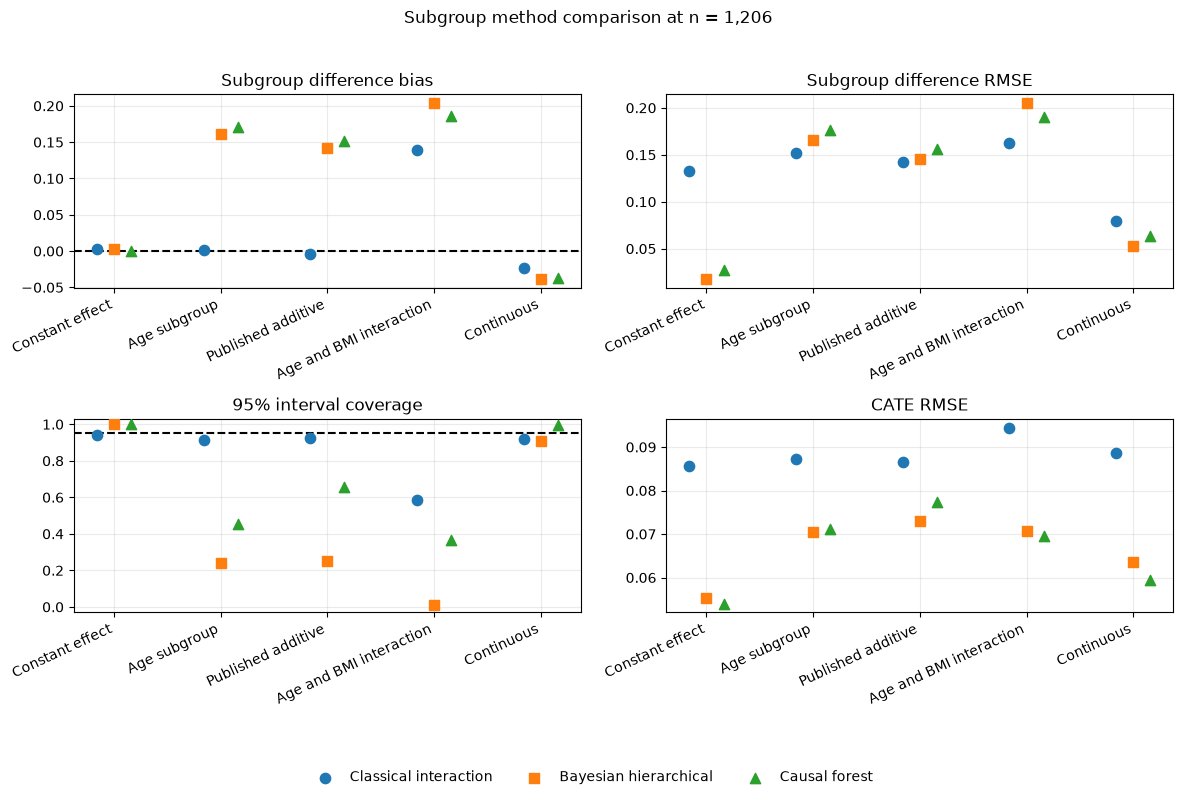

In [17]:
# Run the models or load saved results
if RUN_MAIN_ANALYSIS:
    replication_results = run_main_simulation(replications=N_REPLICATIONS)
    comparison_summary = summarise_main_results(replication_results)
else:
    replication_results = pd.read_csv(OUTPUT_DIRECTORY / "replication_results.csv")
    comparison_summary = pd.read_csv(OUTPUT_DIRECTORY / "summary.csv")

# Plot the results
comparison_figure = plot_comparison(
    comparison_summary,
    OUTPUT_DIRECTORY / "model_comparison.png",
    title=f"Subgroup method comparison at n = {cfg.TOTAL_N:,}"
)

## Bayesian prior sensitivity

This separate robustness analysis fits the Bayesian model under prior scales
0.5, 1, and 2. It always uses 10 replications per scenario, independently of
whether the main analysis is a pilot or final run.

In [18]:
def run_prior_sensitivity(replications):
    """Repeat Bayesian fitting under each prespecified prior scale"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["prior_trials"]
    model_random_generator = random_generators["prior_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(PRIOR_SCALES)
    )
    progress = tqdm(
        total=total_fits, desc="Prior sensitivity", unit="fit", dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Reuse one trial across prior scales
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            # Fit one model for each prior scale
            for prior_scale in PRIOR_SCALES:
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"prior scale {prior_scale:g}"
                )
                fit_seed = int(model_random_generator.integers(0, 2**32))

                try:
                    fitted = fit_bayesian_model(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        prior_scale=prior_scale
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "bayesian_hierarchical", scenario, replication, exception
                    )

                # Store the scale with the result
                row["prior_scale"] = prior_scale
                rows.append(row)
                progress.update(1)

        progress.write(
            f"Prior sensitivity completed "
            f"{cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    # Save detailed sensitivity results
    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_results.csv", index=False)
    return results

def summarise_prior_results(results):
    """Create one summary row for each scenario and prior scale"""
    rows = []

    # Summarise each scenario and scale
    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for prior_scale in PRIOR_SCALES:
            subset = results[
                (results["scenario"] == scenario)
                & (results["prior_scale"] == prior_scale)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["prior_scale"] = prior_scale
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv", index=False)
    return summary

In [19]:
# Run the sensitivity analysis or load saved results
if RUN_PRIOR_SENSITIVITY:
    prior_sensitivity_results = run_prior_sensitivity(
        replications=cfg.PRIOR_SENSITIVITY_REPLICATIONS
    )
    prior_sensitivity_summary = summarise_prior_results(
        prior_sensitivity_results
    )
else:
    prior_sensitivity_results = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_results.csv"
    )
    prior_sensitivity_summary = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv"
    )

prior_sensitivity_summary[
    [
        "scenario_label",
        "prior_scale",
        "usable_replications",
        "subgroup_difference_bias",
        "subgroup_difference_rmse",
        "subgroup_difference_coverage",
        "cate_rmse",
        "nonconvergence_rate"
    ]
].round(3)

Prior sensitivity:  20%|██        | 30/150 [00:28<01:52,  1.06fit/s, Age subgroup | replication 1/10 | prior scale 0.5]    

Prior sensitivity completed Constant effect (10 replications)


Prior sensitivity:  40%|████      | 60/150 [00:58<01:32,  1.03s/fit, Published additive | replication 1/10 | prior scale 0.5]

Prior sensitivity completed Age subgroup (10 replications)


Prior sensitivity:  60%|██████    | 90/150 [01:28<01:00,  1.01s/fit, Age and BMI interaction | replication 1/10 | prior scale 0.5]

...

Prior sensitivity:  80%|████████  | 120/150 [02:04<00:32,  1.07s/fit, Continuous | replication 1/10 | prior scale 0.5]              

Prior sensitivity completed Age and BMI interaction (10 replications)


Prior sensitivity: 100%|██████████| 150/150 [02:32<00:00,  1.02s/fit, Continuous | replication 10/10 | prior scale 2]  

Prior sensitivity completed Continuous (10 replications)


,scenario_label,prior_scale,usable_replications,subgroup_difference_bias,subgroup_difference_rmse,subgroup_difference_coverage,cate_rmse,nonconvergence_rate
0,Constant effect,0.5,10,0.001,0.007,1.0,0.035,0.0
1,Constant effect,1.0,10,0.000,0.009,1.0,0.038,0.0
2,Constant effect,2.0,10,-0.001,0.010,1.0,0.040,0.0
3,Age subgroup,0.5,10,0.166,0.169,0.1,0.065,0.0
4,Age subgroup,1.0,10,0.159,0.163,0.1,0.066,0.0
5,Age subgroup,2.0,10,0.156,0.161,0.2,0.067,0.0
6,Published additive,0.5,10,0.145,0.150,0.2,0.072,0.0
7,Published additive,1.0,10,0.142,0.148,0.2,0.074,0.0
8,Published additive,2.0,10,0.139,0.146,0.3,0.076,0.0
9,Age and BMI interaction,0.5,10,0.217,0.217,0.0,0.066,0.0


## Diagnostics and results

The first table counts failed and non-converged fits. The second shows the
reason for every unusable fit. The final table contains the performance
measures used in the dissertation comparison.

In [20]:
# Count fit outcomes
diagnostics = pd.Series(
    {
        "attempted_fits": len(replication_results),
        "successful_fits": int(replication_results["success"].sum()),
        "failed_fits": int((~replication_results["success"]).sum()),
        "nonconverged_fits": int(
            (
                replication_results["success"]
                & ~replication_results["converged"].fillna(False)
            ).sum()
        )
    },
    name="value"
)
diagnostics

attempted_fits       7500
successful_fits      7500
failed_fits             0
nonconverged_fits      23
Name: value, dtype: int64

In [21]:
# Find failed or non-converged fits
successful = replication_results["success"]
converged = replication_results["converged"].fillna(False)
unusable = ~successful | ~converged

replication_results.loc[
    unusable, ["scenario", "replication", "method", "diagnostic", "error"]
]

,scenario,replication,method,diagnostic,error
235,constant_risk_difference,79,bayesian_hierarchical,"prior scale=1, max R-hat=1.010, minimum bulk E...",
619,constant_risk_difference,207,bayesian_hierarchical,"prior scale=1, max R-hat=1.040, minimum bulk E...",
715,constant_risk_difference,239,bayesian_hierarchical,"prior scale=1, max R-hat=1.010, minimum bulk E...",
751,constant_risk_difference,251,bayesian_hierarchical,"prior scale=1, max R-hat=1.030, minimum bulk E...",
847,constant_risk_difference,283,bayesian_hierarchical,"prior scale=1, max R-hat=1.040, minimum bulk E...",
1456,constant_risk_difference,486,bayesian_hierarchical,"prior scale=1, max R-hat=1.020, minimum bulk E...",
1678,simple_age_subgroup,60,bayesian_hierarchical,"prior scale=1, max R-hat=1.040, minimum bulk E...",
2728,simple_age_subgroup,410,bayesian_hierarchical,"prior scale=1, max R-hat=1.060, minimum bulk E...",
2857,simple_age_subgroup,453,bayesian_hierarchical,"prior scale=1, max R-hat=1.070, minimum bulk E...",
3037,published_heterogeneity,13,bayesian_hierarchical,"prior scale=1, max R-hat=1.003, minimum bulk E...",


In [22]:
# Select the final result columns
result_columns = [
    "scenario_label",
    "method_label",
    "attempted_replications",
    "usable_replications",
    "subgroup_difference_truth",
    "subgroup_difference_bias",
    "subgroup_difference_rmse",
    "subgroup_difference_coverage",
    "subgroup_difference_coverage_mcse",
    "cate_rmse",
    "failure_rate",
    "nonconvergence_rate"
]

comparison_summary[result_columns].round(3)

,scenario_label,method_label,attempted_replications,usable_replications,subgroup_difference_truth,subgroup_difference_bias,subgroup_difference_rmse,subgroup_difference_coverage,subgroup_difference_coverage_mcse,cate_rmse,failure_rate,nonconvergence_rate
0,Constant effect,Classical interaction,500,500,-0.000,0.003,0.133,0.940,0.011,0.086,0.0,0.000
1,Constant effect,Bayesian hierarchical,500,494,-0.000,0.003,0.018,1.000,0.000,0.055,0.0,0.012
2,Constant effect,Causal forest,500,500,-0.000,0.001,0.027,1.000,0.000,0.054,0.0,0.000
3,Age subgroup,Classical interaction,500,500,-0.205,0.001,0.151,0.912,0.013,0.087,0.0,0.000
4,Age subgroup,Bayesian hierarchical,500,497,-0.205,0.161,0.165,0.239,0.019,0.071,0.0,0.006
5,Age subgroup,Causal forest,500,500,-0.205,0.171,0.177,0.456,0.022,0.071,0.0,0.000
6,Published additive,Classical interaction,500,500,-0.177,-0.004,0.142,0.924,0.012,0.087,0.0,0.000
7,Published additive,Bayesian hierarchical,500,496,-0.177,0.142,0.146,0.252,0.019,0.073,0.0,0.008
8,Published additive,Causal forest,500,500,-0.177,0.151,0.156,0.658,0.021,0.077,0.0,0.000
9,Age and BMI interaction,Classical interaction,500,500,-0.225,0.139,0.163,0.586,0.022,0.094,0.0,0.000


# Additional plots

In [23]:
def plot_true_arm_and_difference_boxplots(evaluation_data, path, title=None):
    """Plot both true arm risks and their difference for every scenario"""
    figure, axes = plt.subplots(
        2, 3, figsize=(12, 8), sharex=False, sharey=True
    )
    contrast_color = "#1B9E77"

    for axis, scenario in zip(axes.flat, cfg.PRIMARY_ANALYSIS_SCENARIOS):
        placebo_risk, semaglutide_risk = cfg.calculate_outcome_probabilities(
            evaluation_data, scenario
        )
        risk_difference = semaglutide_risk - placebo_risk

        boxplot = axis.boxplot(
            [semaglutide_risk, risk_difference, placebo_risk],
            positions=[1, 2, 3],
            widths=0.5,
            whis=(0, 100),
            showfliers=False,
            patch_artist=True,
            medianprops={"color": "black", "linewidth": 1.5},
            boxprops={"edgecolor": "black", "linewidth": 1.5},
            whiskerprops={"color": "black", "linewidth": 1.5},
            capprops={"color": "black", "linewidth": 1.5}
        )

        for box in boxplot["boxes"]:
            box.set_facecolor("white")

        # Highlight the middle risk-difference box as in the reference sketch
        boxplot["boxes"][1].set_edgecolor(contrast_color)
        boxplot["medians"][1].set_color(contrast_color)
        for line in boxplot["whiskers"][2:4] + boxplot["caps"][2:4]:
            line.set_color(contrast_color)

        axis.axhline(
            cfg.AVERAGE_CATE_TARGET,
            color="#B22222",
            linestyle="--",
            linewidth=1.25
        )
        axis.set_title(cfg.SCENARIO_LABELS[scenario])
        axis.set_xticks(
            [1, 2, 3], ["Semaglutide", "Difference", "Placebo"], rotation=20
        )
        axis.set_ylim(0, 1)
        axis.grid(axis="y", alpha=0.25)

    # Use the unused panel for the visual key
    legend_axis = axes.flat[-1]
    legend_axis.axis("off")
    legend_axis.plot(
        [], [], color="black", linewidth=1.5, label="Arm response probability"
    )
    legend_axis.plot(
        [], [], color=contrast_color, linewidth=1.5, label="Risk difference (CATE)"
    )
    legend_axis.plot(
        [],
        [],
        color="#B22222",
        linestyle="--",
        linewidth=1.25,
        label="Population ATE"
    )
    legend_axis.legend(loc="center", frameon=False)

    figure.supylabel("True response probability or risk difference")
    if title is not None:
        figure.suptitle(title)
    top = 0.94 if title is not None else 1
    figure.tight_layout(rect=(0, 0, 1, top))
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

# Create dissertation-use title-free versions of both figures

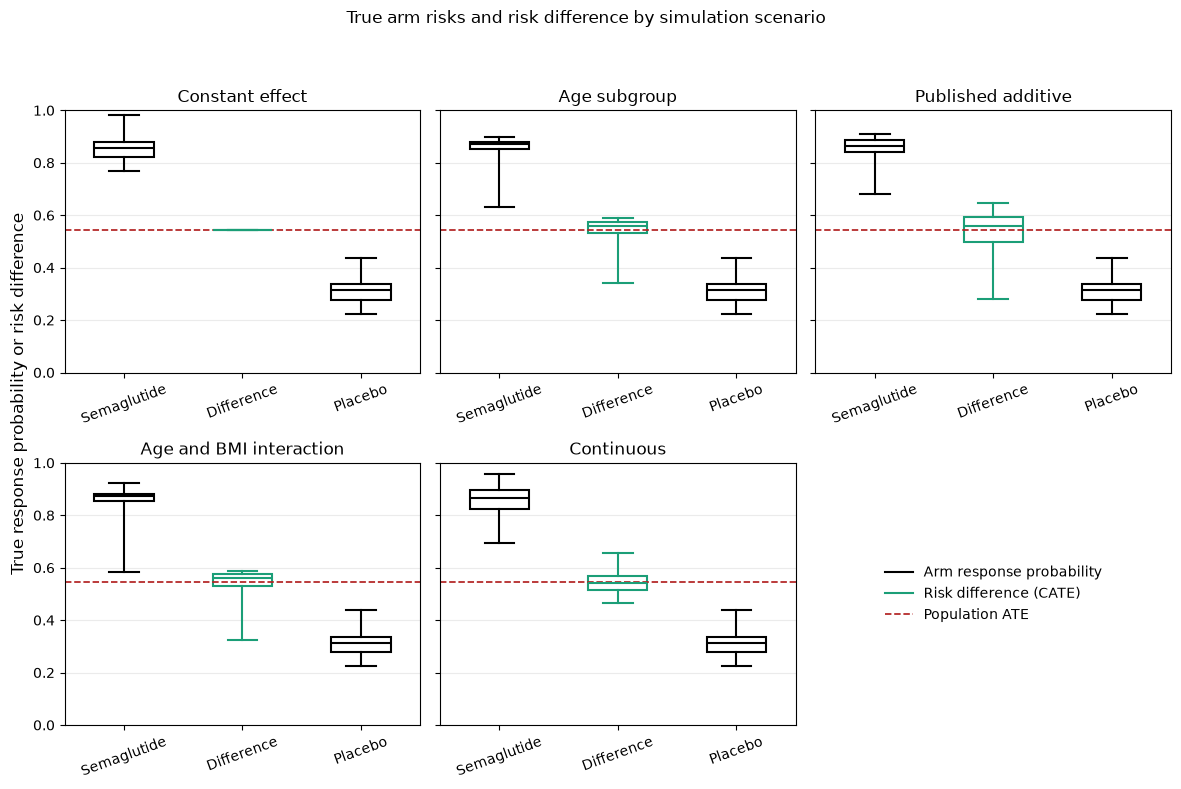

In [24]:
# Plot the arm risks and their differences with a title for the notebook
true_cate_figure = plot_true_arm_and_difference_boxplots(
    evaluation_population,
    OUTPUT_DIRECTORY / "true_cate_scenarios.png",
    title="True arm risks and risk difference by simulation scenario"
)

# Save title-free versions for use with document captions
comparison_no_title_path = OUTPUT_DIRECTORY / "model_comparison_no_title.png"
comparison_figure_no_title = plot_comparison(
    comparison_summary, comparison_no_title_path
)
truth_no_title_path = OUTPUT_DIRECTORY / "true_cate_scenarios_no_title.png"
truth_figure_no_title = plot_true_arm_and_difference_boxplots(
    evaluation_population, truth_no_title_path
)

# Display only the titled figure in the notebook
plt.close(comparison_figure_no_title)
plt.close(truth_figure_no_title)